In [1]:
import backtrader as bt
import datetime
import pandas as pd
import numpy as np


In [2]:
dataframe = pd.read_csv('./csv_files/000300.XSHG.csv', parse_dates=True, index_col=0)

# pandasdata feeder
feed = bt.feeds.PandasData(dataname=dataframe, openinterest=None)

In [3]:
class ColorSAR(bt.Indicator):
    params = (
        ('af', 0.02),
        ('afmax', 0.2),
    )
    lines = ('upsar','downsar','sar','close')

    plotlines = dict( 
        upsar = dict(
            marker='o',
            markersize=2.0,
            color='red',
            fillstyle='full',
            ls='',
        ),
        downsar = dict(
            marker='o',
            markersize=2.0,
            color='green',
            fillstyle='full',
            ls='',
        ),
        sar = dict(
            _plotskip=True,
        ),
        close = dict(
            _plotskip=True,
        )
    )
    plotinfo = {
        'subplot':False,
    }

    def __init__(self):
#         input_dict = {
#             'startvalue': 0.0,
#             'offsetonreverse': 0.0,
#         }
#         self.l.sar = bt.talib.SAREXT(
#             self.data.high,
#             self.data.low,
#             **input_dict
#             )
        self.l.sar = bt.ind.PSAR(self.data,af=self.p.af,afmax=self.p.afmax)
        self.l.close = self.data.close

    def next(self):
        self.l.upsar[0] = self.l.sar[0] if self.l.sar[0]>self.l.close[0] else np.nan
        self.l.downsar[0] = self.l.sar[0] if self.l.sar[0]<self.l.close[0] else np.nan

In [4]:
# Stratey
class SarDmiStrategy(bt.Strategy):
    '''
    Empty strategy is used to study indicators
    '''
    params = (
        ('startvalue', 0.0),
        ('offsetonreverse', 0.0),
        ('print_trade_detail', True),
    )
    
    def log(self, txt):
        ''' Logging function for this strategy'''
        dt = self.datas[0].datetime.date(0)
        print('%s, %s' % (dt.isoformat(), txt))
        
    def _output_order_details(self, order):
        ''' Log order details '''
        if order.isbuy():
            self.log('BUY EXECUTED, Size: %d, Price: %.2f, Cost: %.2f, Comm %.2f' %
                     (order.executed.size,
                      order.executed.price,
                      order.executed.value,
                      order.executed.comm))
        else:  # Sell
            self.log('SELL EXECUTED, Size: %d, Price: %.2f, Cost: %.2f, Comm %.2f' %
                     (order.executed.size,
                      order.executed.price,
                      order.executed.value,
                      order.executed.comm))

    def __init__(self):
        # use idx300
        d1 = self.dnames.idx300day
        
        self.sar = ColorSAR(d1)
        self.dm = bt.ind.DM(d1,period=7)
        self.dm2 = bt.ind.DM(d1,period=14)
    
        self.cross = bt.indicators.CrossOver(d1.close, self.sar.sar, plot=False)
        self.buy_signal = self.cross==1
        self.sell_signal = self.cross==-1
        
        # To keep track of pending orders
        self.order = None
        
    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            # Buy/Sell order submitted/accepted to/by broker - Nothing to do
            return
        # Check if an order has been completed
        # Attention: broker could reject order if not enough cash
        if self.p.print_trade_detail and order.status == order.Completed:
            self._output_order_details(order)

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('Order Canceled/Margin/Rejected')
        
        self.order = None
        
    def next(self):
        # Check if an order is pending ... if yes, we cannot send a 2nd one
        if self.order:
            return
        
        # Check if we are in the market
        if not self.position:
            # Not yet ... we MIGHT BUY if ...
            if self.buy_signal[0]:
                # BUY, BUY, BUY!!! (with all possible default parameters)
                self.order = self.buy()
        else:
            # Already in the market ... we might sell
            if self.sell_signal[0]:
                # SELL, SELL, SELL!!! (with all possible default parameters)
                self.order = self.sell()
    
    def stop(self):
        pass

In [5]:
cerebro = bt.Cerebro() # oldtrades=False, stdstats=False

cerebro.adddata(feed, name='idx300day')
#cerebro.resampledata(feed, name='cy_weekly', timeframe=bt.TimeFrame.Weeks)

cerebro.addstrategy(SarDmiStrategy, print_trade_detail=False)
# cerebro.addstrategy(EmptyStrategy)

# exp indicators
#cerebro.addindicator(bt.talib.AROON,feed.high,feed.low)

# 小场面1万起始资金
cerebro.broker.setcash(100000.0)

# 手续费万5
cerebro.broker.setcommission(0.0005)

cerebro.broker.set_coc(True)
#cerebro.broker.set_fundstartval(50)

cerebro.addsizer(bt.sizers.AllInSizerInt, percents=99)

cerebro.addanalyzer(bt.analyzers.AnnualReturn)
#cerebro.addanalyzer(bt.analyzers.PyFolio)
cerebro.addanalyzer(bt.analyzers.TimeDrawDown)
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer)
cerebro.addanalyzer(bt.analyzers.SQN)
cerebro.addanalyzer(bt.analyzers.VWR)
cerebro.addanalyzer(bt.analyzers.SharpeRatio, riskfreerate=0.02)

print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())

result = cerebro.run()

print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())

Starting Portfolio Value: 100000.00
Final Portfolio Value: 639316.62


In [6]:
strat = result[0]
for a_name in strat.analyzers.getnames():
    strat.analyzers.getbyname(a_name).pprint()

OrderedDict([(2005, 0.10139761199999997),
             (2006, 0.7314253592643523),
             (2007, 1.0127880824208937),
             (2008, -0.3180737875574333),
             (2009, 0.5858647347057435),
             (2010, -0.015070694151256725),
             (2011, -0.17276307763443055),
             (2012, 0.051250842980473665),
             (2013, -0.11184677254622144),
             (2014, 0.21065834225491553),
             (2015, 0.2520027326578056),
             (2016, 0.030954111783353833),
             (2017, 0.09987815308035408),
             (2018, -0.07793532764420386),
             (2019, 0.17591890024991952),
             (2020, 0.12583685861606275),
             (2021, -0.03503339208230205)])
OrderedDict([('maxdrawdown', 41.63915556194494), ('maxdrawdownperiod', 1304)])
AutoOrderedDict([('total',
                  AutoOrderedDict([('total', 172),
                                   ('open', 0),
                                   ('closed', 172)])),
                 ('st

<IPython.core.display.Javascript object>


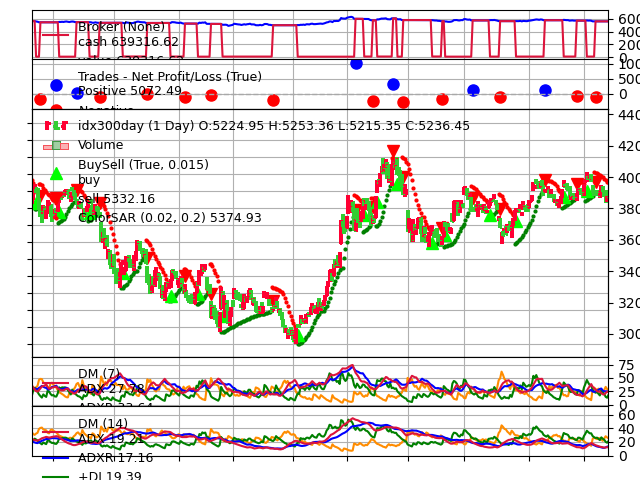

[[<Figure size 640x480 with 6 Axes>]]

In [6]:
line_params = dict(
    style='line',
    loc = 'black',
    volup='#F66269',
    voldown='#43A047',
)

candle_params = dict(
    style='bar',
    barup='#FF0033',
    bardown='#32CD32',
    volup='#F66269',
    voldown='#43A047',
)

cerebro.plot(
    iplot=True, 
#     **line_params
    **candle_params
)

In [6]:
from backtrader_plotting import Bokeh
from bokeh.plotting import output_file

output_file('bpplot.html')

# separate labels
plotconfig = {
    'r:^Broker.*': dict(
        plotlinelabels=True,
    ),
    'r:^Trades.*': dict(
        plotlinelabels=True,
    ),
    'r:^DM.*': dict(
        plotlinelabels=True,
    ),
}
b = Bokeh(plotconfig=plotconfig, output_mode='save', style='bar')
cerebro.plot(b)

Loading BokehJS ...

[[<backtrader_plotting.bokeh.bokeh.FigurePage at 0x6b9690a0>]]